# 09 - Stage 5 Splits + Packaging QA

Visual checks on the split metadata + packaged per-fold parquets produced by
`scripts/run_stage5.py`. Per CLAUDE.md acceptance #5: **splits must be by image
(group-aware), never random per-tile**. Tiles within an image share illumination,
surface composition, and BoulderNet detector behaviour, so a random per-tile split
leaks the per-image background into the test fold and inflates every downstream metric.

Two schemes shipped (decisions locked in via AskUserQuestion 2026-05-24):

- **`loio_9fold`** -- true leave-one-image-out. 9 folds, 1 ObsId per test fold.
  Honest per-image variance for headline numbers.
- **`loio_3fold_balanced`** -- 3 image-balanced test folds. Smoother per-fold metric
  variance; useful when 9-fold's single-image test sets are too noisy.

Sanity checks below:

1. Per-image tile counts + manifest BoulderLabel.
2. Per-scheme fold composition (image count + label distribution).
3. Per-fold target distribution -- train vs test `fractional_area`, finest scale.
4. **Group-leak assertion** -- no `obs_id` appears in both train and test for any fold.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import manifest as M
from src.config import load_config
from src.dataset import (
    FEATURES_SUBDIR, LABELS_SUBDIR, PACKAGED_SUBDIR, SPLITS_SUBDIR,
    build_image_inventory, discover_obs_ids, load_package_metadata, load_split_metadata,
)

FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(REPO_ROOT / 'config.yaml')
manifest_df = M.load_manifest(cfg.manifest_path)
labels_dir = cfg.output_dir / LABELS_SUBDIR
obs_ids = discover_obs_ids(labels_dir)
inv = build_image_inventory(obs_ids, manifest_df, labels_dir)
scheme_names = list(cfg['splits']['schemes'])
print(f'{len(obs_ids)} ObsIds; schemes available: {scheme_names}')

LABEL_COLORS = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue', 'unknown': 'tab:gray'}

inv_display = inv.sort_values('n_tiles_total', ascending=False)
print('\nPer-image inventory (sorted by n_tiles_total):')
print(inv_display.to_string())


9 ObsIds; schemes available: ['loio_9fold', 'loio_3fold_balanced']

Per-image inventory (sorted by n_tiles_total):
                 BoulderLabel  n_tiles_total  n_tiles_finest  frac_mean_finest  n_polys_after_filter
ObsId                                                                                               
ESP_055714_2270  Boulder rich         100558           76030          0.000554                  1974
ESP_069669_2220  Boulder rich          96354           72821          0.000099                  1462
ESP_056165_2200  Boulder poor          95403           73335          0.000001                    26
ESP_071093_2210  Boulder rich          73958           55962          0.000100                   961
ESP_047976_2020  Boulder rich          71449           54054          0.000080                  1346
ESP_039820_1750       unknown          65081           49279          0.000073                   497
ESP_075577_2105  Boulder poor          58908           44560          0.00005

## Per-image tile counts

Bar chart of `n_tiles_total` per image, colored by manifest `BoulderLabel`. The
spread (33k - 100k tiles) is wide enough that per-fold sample counts vary noticeably
under any image-grouped split, even when the *number of images* per fold is balanced.


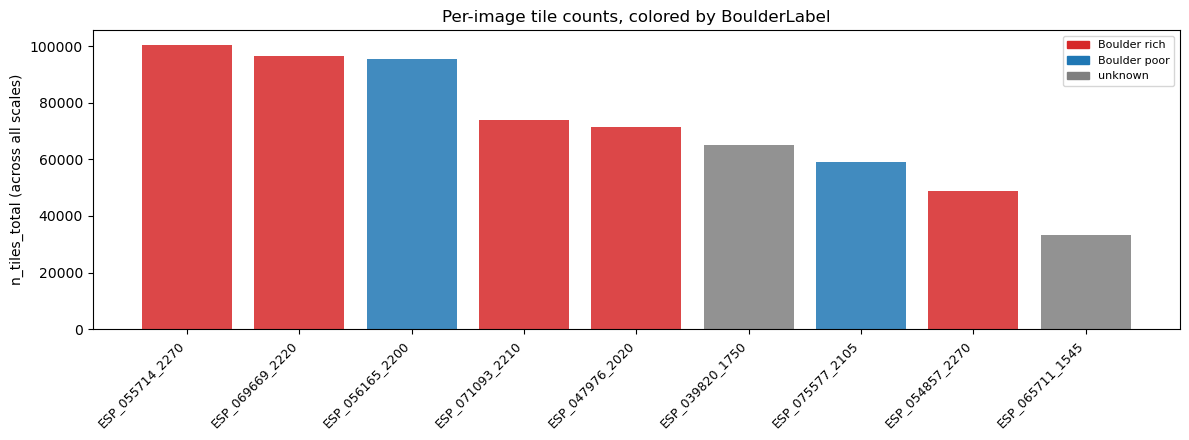

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.5))
inv_sorted = inv.sort_values('n_tiles_total', ascending=False)
colors = [LABEL_COLORS[lab] for lab in inv_sorted['BoulderLabel']]
ax.bar(inv_sorted.index, inv_sorted['n_tiles_total'], color=colors, alpha=0.85)
ax.set_ylabel('n_tiles_total (across all scales)')
ax.set_title('Per-image tile counts, colored by BoulderLabel')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
# Build a custom legend.
from matplotlib import patches as mpatches
handles = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
ax.legend(handles=handles, fontsize=8, loc='upper right')
fig.tight_layout()
fig.savefig(FIG_DIR / '09_inventory.png', dpi=110)
plt.show()


## Per-scheme fold composition

For each scheme, show:
- which ObsIds land in which test fold,
- per-fold image count + label distribution,
- per-fold tile count.

The 9-fold view is trivial (one ObsId per test fold by construction); the 3-fold view
is the interesting case -- size-balanced greedy assignment puts 3 images in each test
fold, but the label composition isn't perfectly balanced because we only have 2 poor
and 2 unknown images among 9.


In [3]:
def fold_composition_table(meta):
    rows = []
    for fold in meta['folds']:
        ts = fold['test_summary']
        row = {
            'fold_idx': fold['fold_idx'],
            'test_obs_ids': ' '.join(fold['test_obs_ids']),
            'n_test_images': ts['n_images'],
            'n_test_tiles': ts['n_tiles_total'],
            'frac_mean_finest_avg': ts['frac_mean_finest_avg'],
        }
        # Add per-label counts as separate columns.
        for label in ['Boulder rich', 'Boulder poor', 'unknown']:
            row[f'test_{label.replace(" ", "_")}'] = ts['boulder_labels'].get(label, 0)
        rows.append(row)
    return pd.DataFrame(rows).set_index('fold_idx')

for scheme in scheme_names:
    meta = load_split_metadata(scheme, cfg.output_dir)
    tbl = fold_composition_table(meta)
    print(f'\n=== {scheme} ===')
    print(tbl.to_string())



=== loio_9fold ===
             test_obs_ids  n_test_images  n_test_tiles  frac_mean_finest_avg  test_Boulder_rich  test_Boulder_poor  test_unknown
fold_idx                                                                                                                        
0         ESP_039820_1750              1         65081              0.000073                  0                  0             1
1         ESP_047976_2020              1         71449              0.000080                  1                  0             0
2         ESP_054857_2270              1         48875              0.001106                  1                  0             0
3         ESP_055714_2270              1        100558              0.000554                  1                  0             0
4         ESP_056165_2200              1         95403              0.000001                  0                  1             0
5         ESP_065711_1545              1         33324              0.000000 

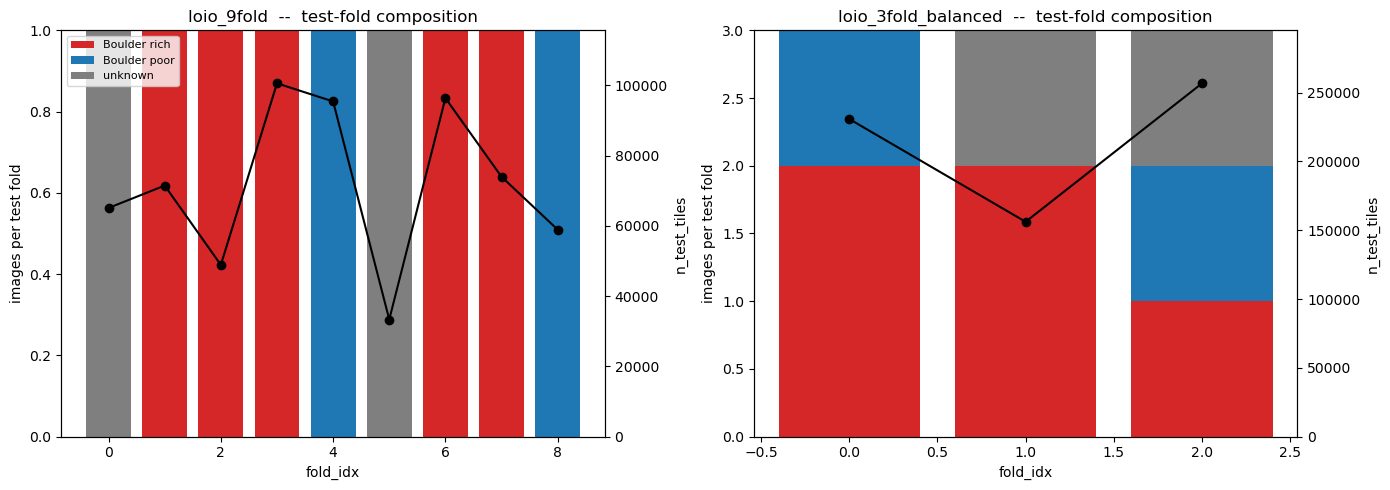

In [4]:
# Per-scheme bar plot: stacked label composition per fold + tile-count line.
fig, axes = plt.subplots(1, len(scheme_names), figsize=(7 * len(scheme_names), 5),
                          squeeze=False)
for ax, scheme in zip(axes[0], scheme_names):
    meta = load_split_metadata(scheme, cfg.output_dir)
    folds = meta['folds']
    fold_idx = [f['fold_idx'] for f in folds]
    rich_count = [f['test_summary']['boulder_labels'].get('Boulder rich', 0) for f in folds]
    poor_count = [f['test_summary']['boulder_labels'].get('Boulder poor', 0) for f in folds]
    unk_count = [f['test_summary']['boulder_labels'].get('unknown', 0) for f in folds]
    ax.bar(fold_idx, rich_count, color=LABEL_COLORS['Boulder rich'], label='Boulder rich')
    ax.bar(fold_idx, poor_count, bottom=rich_count,
           color=LABEL_COLORS['Boulder poor'], label='Boulder poor')
    bottom_for_unk = np.array(rich_count) + np.array(poor_count)
    ax.bar(fold_idx, unk_count, bottom=bottom_for_unk,
           color=LABEL_COLORS['unknown'], label='unknown')
    # Tile-count line on a secondary axis.
    ax2 = ax.twinx()
    tile_counts = [f['test_summary']['n_tiles_total'] for f in folds]
    ax2.plot(fold_idx, tile_counts, color='black', marker='o', linewidth=1.5,
             label='n_test_tiles')
    ax2.set_ylabel('n_test_tiles', color='black')
    ax2.set_ylim(0, max(tile_counts) * 1.15)
    ax.set_xlabel('fold_idx')
    ax.set_ylabel('images per test fold')
    ax.set_title(f'{scheme}  --  test-fold composition')
    if ax is axes[0][0]:
        ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / '09_fold_composition.png', dpi=110)
plt.show()


## Per-fold target distribution (train vs test, finest scale)

The single thing most likely to bite a model in evaluation: a fold whose **test set has
a wildly different target distribution from its train set**. CLAUDE.md §9 already warns
the target is heavily zero-inflated -- this sanity-check is the visual version of
"no fold is pathological". For each scheme, render the per-fold `fractional_area`
distribution (log-scaled) on the train vs test sides; flag any fold where the test
distribution looks like a different population than the train one.


C:\Users\brian\anaconda3\envs\geospatial\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


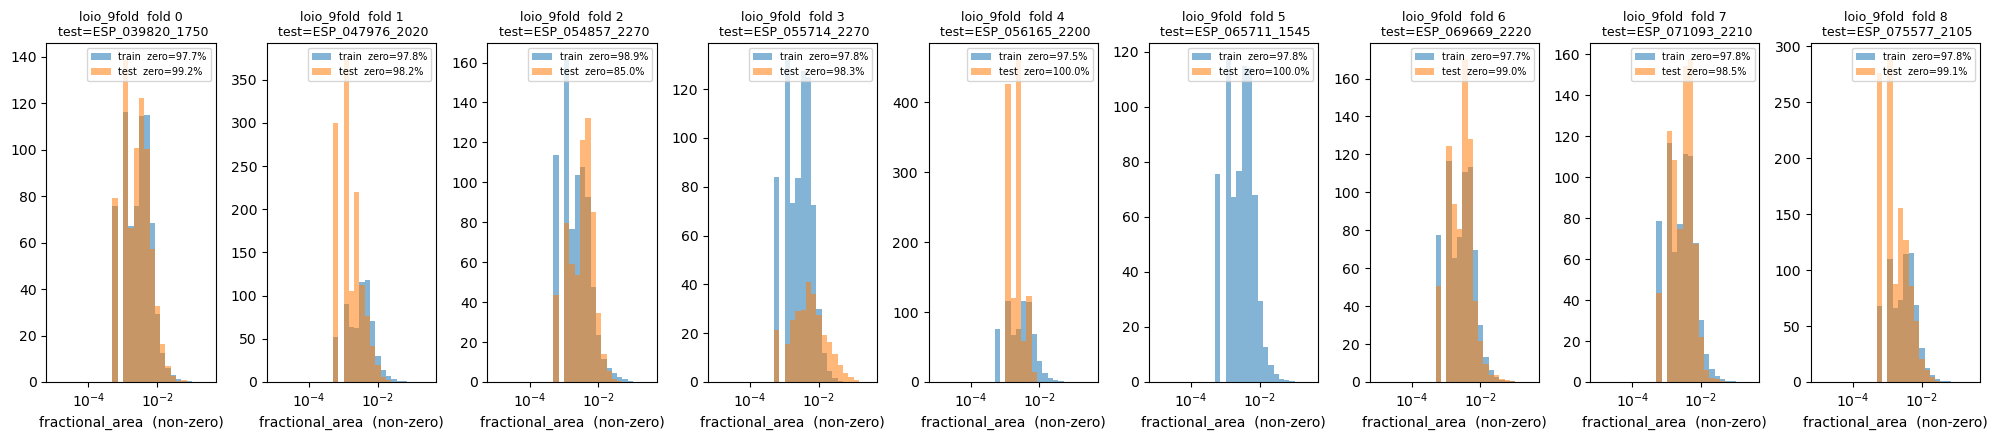

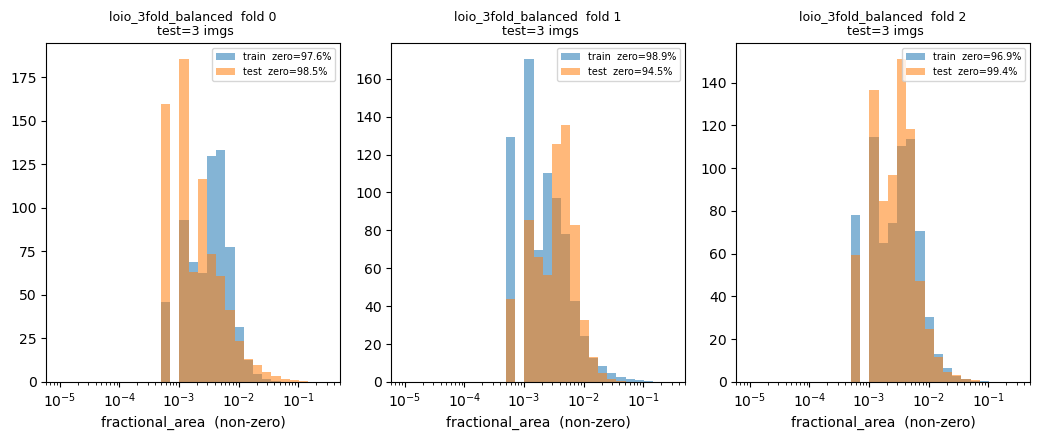

In [5]:
def plot_train_test_per_fold(scheme):
    pkg_dir = cfg.output_dir / PACKAGED_SUBDIR / scheme
    meta = load_split_metadata(scheme, cfg.output_dir)
    n = len(meta['folds'])
    fig, axes = plt.subplots(1, n, figsize=(min(20, 3.5 * n), 4.5), squeeze=False)
    for ax, fold in zip(axes[0], meta['folds']):
        k = fold['fold_idx']
        y_train = pd.read_parquet(pkg_dir / f'y_train_fold{k}.parquet',
                                    columns=['tile_size_px', 'fractional_area'])
        y_test = pd.read_parquet(pkg_dir / f'y_test_fold{k}.parquet',
                                   columns=['tile_size_px', 'fractional_area'])
        train_finest = y_train[y_train['tile_size_px'] == y_train['tile_size_px'].min()]
        test_finest = y_test[y_test['tile_size_px'] == y_test['tile_size_px'].min()]
        # Log-scaled histogram of nonzero values + zero spike count.
        nz_train = train_finest[train_finest['fractional_area'] > 0]['fractional_area']
        nz_test = test_finest[test_finest['fractional_area'] > 0]['fractional_area']
        zero_train_pct = (train_finest['fractional_area'] == 0).mean() * 100
        zero_test_pct = (test_finest['fractional_area'] == 0).mean() * 100
        bins = np.logspace(-5, np.log10(0.3), 30)
        ax.hist(nz_train, bins=bins, density=True, alpha=0.55,
                color='tab:blue', label=f'train  zero={zero_train_pct:.1f}%')
        ax.hist(nz_test, bins=bins, density=True, alpha=0.55,
                color='tab:orange', label=f'test  zero={zero_test_pct:.1f}%')
        ax.set_xscale('log')
        ax.set_xlabel('fractional_area  (non-zero)')
        test_ids = fold['test_obs_ids']
        test_label = test_ids[0] if len(test_ids) == 1 else f'{len(test_ids)} imgs'
        ax.set_title(f'{scheme}  fold {k}\n test={test_label}', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'09_target_dist_{scheme}.png', dpi=110)
    plt.show()

for scheme in scheme_names:
    plot_train_test_per_fold(scheme)


## Group-leak assertion (the only correctness check that matters)

For every scheme, every fold, every train-vs-test pair: the set of test ObsIds and the
set of train ObsIds must be disjoint. The split is over images, not tiles, so a leak
here means a downstream model could see exact-same-illumination, exact-same-detector-
output tiles in train AND test. The assertion below fails loudly if that ever happens.


In [6]:
for scheme in scheme_names:
    meta = load_split_metadata(scheme, cfg.output_dir)
    pkg = load_package_metadata(scheme, cfg.output_dir)
    print(f'=== {scheme} ===')
    for fold in meta['folds']:
        train = set(fold['train_obs_ids'])
        test = set(fold['test_obs_ids'])
        leak = train & test
        assert not leak, f'{scheme} fold {fold["fold_idx"]}: leak {leak}'
        # Also assert that the materialized X parquets respect the split metadata.
        pkg_dir = cfg.output_dir / PACKAGED_SUBDIR / scheme
        x_train_obs = set(pd.read_parquet(pkg_dir / f'X_train_fold{fold["fold_idx"]}.parquet',
                                             columns=['obs_id'])['obs_id'].unique())
        x_test_obs = set(pd.read_parquet(pkg_dir / f'X_test_fold{fold["fold_idx"]}.parquet',
                                            columns=['obs_id'])['obs_id'].unique())
        assert x_train_obs == train, (scheme, fold['fold_idx'], 'train obs mismatch')
        assert x_test_obs == test, (scheme, fold['fold_idx'], 'test obs mismatch')
        print(f'  fold {fold["fold_idx"]:>2}: train_obs={len(train)} test_obs={len(test)} '
              f'leak={"NO" if not leak else leak}  pkg_obs_match=OK')
    print(f'  split_hash={meta["split_hash"][:16]}...  pkg metadata_split_hash matches: '
          f'{meta["split_hash"] == pkg["split_hash"]}')
print('\nAll group-leak assertions passed.')


=== loio_9fold ===
  fold  0: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  1: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  2: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  3: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  4: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  5: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  6: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK


  fold  7: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  fold  8: train_obs=8 test_obs=1 leak=NO  pkg_obs_match=OK
  split_hash=508fd772eaa0f417...  pkg metadata_split_hash matches: True
=== loio_3fold_balanced ===
  fold  0: train_obs=6 test_obs=3 leak=NO  pkg_obs_match=OK
  fold  1: train_obs=6 test_obs=3 leak=NO  pkg_obs_match=OK
  fold  2: train_obs=6 test_obs=3 leak=NO  pkg_obs_match=OK
  split_hash=39752bed940a1e43...  pkg metadata_split_hash matches: True

All group-leak assertions passed.


## Summary

What was emitted and where:

```
dataset/splits/{scheme}.json                       # split metadata + per-fold summary
dataset/packaged/{scheme}/
    X_train_fold{k}.parquet  y_train_fold{k}.parquet
    X_test_fold{k}.parquet   y_test_fold{k}.parquet
    groups_train_fold{k}.npy groups_test_fold{k}.npy
    all.parquet              # consolidated view with fold_idx column
    metadata.json            # packaging provenance
```

How to train a model on this output:

```python
import pandas as pd, numpy as np
from src.dataset import load_split_metadata

meta = load_split_metadata('loio_9fold', 'dataset')
for fold in meta['folds']:
    k = fold['fold_idx']
    X_train = pd.read_parquet(f'dataset/packaged/loio_9fold/X_train_fold{k}.parquet')
    y_train = pd.read_parquet(f'dataset/packaged/loio_9fold/y_train_fold{k}.parquet')
    X_test  = pd.read_parquet(f'dataset/packaged/loio_9fold/X_test_fold{k}.parquet')
    y_test  = pd.read_parquet(f'dataset/packaged/loio_9fold/y_test_fold{k}.parquet')
    groups  = np.load(f'dataset/packaged/loio_9fold/groups_train_fold{k}.npy')
    # X is keyed by (obs_id, scale_idx, tile_size_px, ti, tj) + feature columns
    # y is keyed identically + label columns + tile-bound context
    # groups is the int-encoded obs_id per row, for sklearn's GroupKFold etc.
    ...
```

For the streaming alternative (recommended at 50+ images, see PLAN_Stage5.md §11b):

```python
from src.dataset import iter_train_batches, iter_test_batches

for fold in meta['folds']:
    k = fold['fold_idx']
    for batch in iter_train_batches(meta, fold_idx=k,
                                       labels_dir='dataset/labels',
                                       features_dir='dataset/features'):
        # batch is one ObsId's joined labels + features
        ...
```

Decisions to revisit downstream:

- **Scale filter** -- currently `null` (every scale included). For a fast modeling
  baseline you may want to restrict to `[8]` (finest) or `[8, 16, 32, 64]` (all).
- **3-fold balancing** -- with 5 rich + 2 poor + 2 unknown images, label composition
  in the 3-fold scheme can't be perfectly equal across folds. The greedy assignment
  picks sizes 3/3/3 with the closest-to-uniform label distribution it can.
- **ESP_065711_1545** (empty shapefile, true-zero tiles) is included as `unknown`. The
  modeling stage may want to filter it out of regression training (its `fractional_area`
  is always exactly 0) but keep it for binary-classification negative examples.
